In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import stats
import seaborn as sn
import pandas as pd
from sklearn.metrics import confusion_matrix

In [3]:
sn.set_theme(context="paper", style="whitegrid", font='sans-serif', color_codes=True, rc=None)


In [4]:
LABELS = ["SPH_9", "BH_n4_M8", "BH_n2_M10", "BH_n4_M10", "BH_n6_M10", "BH_n4_M12"]
paper_colors = ['#4c72b0','#dd8452', '#55a868',  '#c44e52',  '#8172b3', '#937860']
CLASSES = len(LABELS)
LOAD_FOLDER = "../results/predictions/resnet"
MODEL_NAME = "thesis_ensemble"
LOAD_PATH = f"{LOAD_FOLDER}/{MODEL_NAME}.csv"
df = pd.read_csv(LOAD_PATH)
datasets = [0]*CLASSES
for i in range(CLASSES):
    df_temp = df[df["Truth"] == i ]
    datasets[i] = df_temp

#Calculate expected frequencies
cf_matrix = confusion_matrix(df["Truth"].astype(int), df["Prediction"].astype(int), normalize="true")
expected_frequencies = np.array([row[i] for i, row in enumerate(cf_matrix)])

In [5]:
def binomial_probability(k, n, nu):
    if k > n:
        print("k is larger than n!!")
        print(n, k)
    coeff = (math.factorial(n))/(math.factorial(k)*math.factorial(n-k))
    return coeff*(nu**k)*(1-nu)**(n-k)

In [6]:
def poisson_probability(k, n, nu):
    if k > n:
        print("k is larger than n!!")
        print(n, k)
    lambda_val = nu*n
    return lambda_val**k*np.exp(-lambda_val)/math.factorial(k)

In [25]:
def p_value(k, n, nu_exp, stat="binomial"):
    p = 0
    for i in range(0, k+1):
        if stat=="binomial":
            p = p + binomial_probability(i, n, nu_exp)
        elif stat=="poisson":
            p = p + poisson_probability(i, n, nu_exp)
        else:
            return None
    return p

def weighted_percentile(values, weights, percentile_lower, percentile_upper):
    # Only works for convex distribution
    df = pd.DataFrame({"values":values, "weights":weights})
    df = df.sort_values(by="values")
    percentile_added = 0
    lower_limit_found = False
    upper_limit_found = False
    lower_limit = df["values"].min()
    upper_limit = df["values"].max()
    for i in range(len(df)):
        #Keep lower limit BELOW
        if lower_limit_found == False:
            lower_limit = df["values"][i]
        percentile_added = percentile_added + df["weights"][i]*100
        if (percentile_added >= percentile_lower) and (lower_limit_found == False):
            lower_limit_found = True
            #print("Actual lower limit percentile: ", percentile_added)
        #And upper ABOVE
        if (percentile_added >= percentile_upper) and (upper_limit_found == False):
            upper_limit = df["values"][i]
            upper_limit_found = True
            #print("Actual upper limit percentile: ", percentile_added)
        if upper_limit_found:
            return lower_limit, upper_limit
    return lower_limit, upper_limit


[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100]


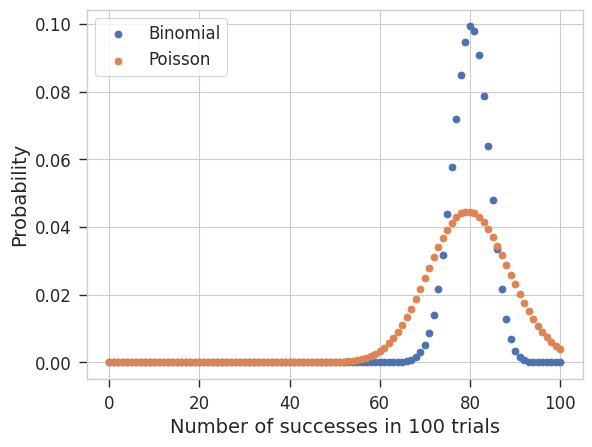

In [8]:
N = 100
nu = 0.8
k_list = np.arange(0, N+1)
print(k_list)
probs_binomial = [binomial_probability(k, N, nu) for k in k_list]
probs_poisson = [poisson_probability(k, N, nu) for k in k_list]

fig, ax = plt.subplots()
ax.scatter(k_list, probs_binomial, label="Binomial")
ax.scatter(k_list, probs_poisson, label="Poisson")
ax.set_xlabel(f"Number of successes in {N} trials", fontsize=14)
ax.set_ylabel("Probability", fontsize=14)
ax.legend(fontsize=12)
ax.tick_params(which="major", direction="out", bottom=True, left=True, pad=5, length=6, width=1, labelsize=12)

Text(0, 0.5, 'Possible frequencies')

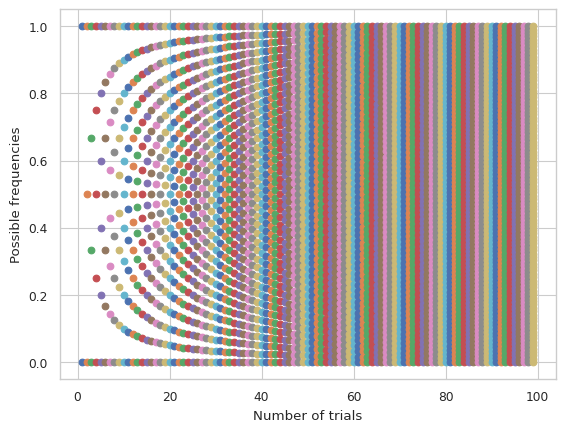

In [9]:
n_list = np.arange(1, 100)
frequencies = [[0]*(n) for n in n_list]
probabilites = [[0]*(n) for n in n_list]
nu=0.3

for i, n in enumerate(n_list):
    k_list = np.arange(0, n+1)
    frequencies[i] = [k/n for k in k_list]
    probabilites[i] = [binomial_probability(k, n, nu) for k in k_list]

fig, ax = plt.subplots()
for i in range(len(n_list)):
    f_values = frequencies[i]
    ax.scatter([n_list[i]]*len(f_values), f_values)
ax.set_xlabel("Number of trials")
ax.set_ylabel("Possible frequencies")

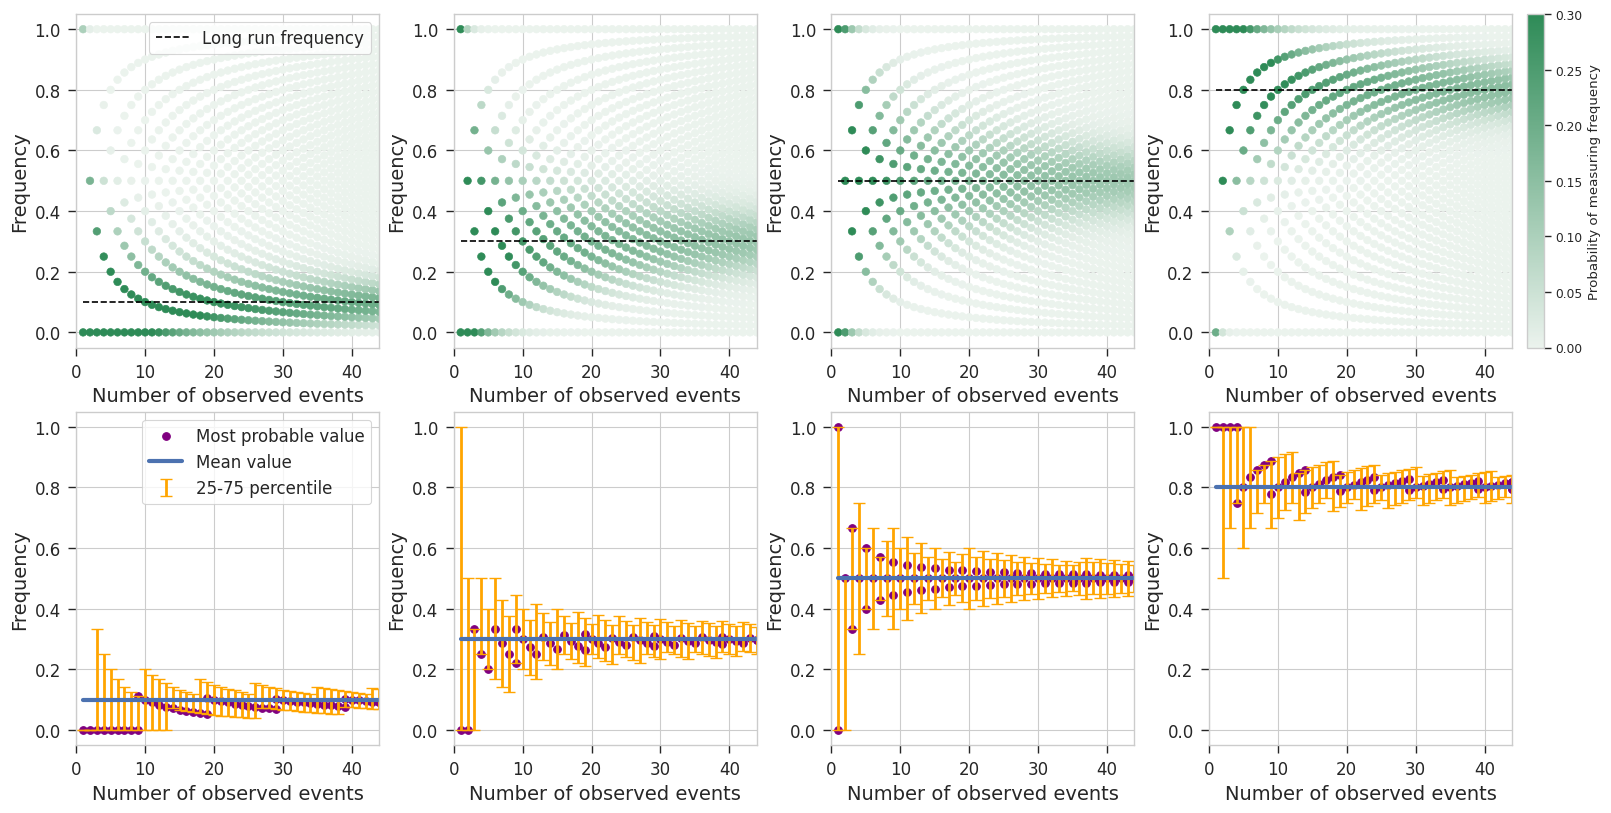

In [10]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16,8), layout="constrained")

n_list = np.arange(1, 45)
nu_vals = [0.1, 0.3, 0.5, 0.8]
tol = 0.001

for i, nu in enumerate(nu_vals):
    mean_vals = np.zeros(len(n_list))
    #most_prob_vals = np.zeros(len(n_list))
    err_up = np.zeros(len(n_list))
    err_down = np.zeros(len(n_list))
    norm = plt.Normalize(0, 0.3)
    sm = plt.cm.ScalarMappable(cmap=sn.light_palette("seagreen", as_cmap=True), norm=norm)
    for j in range(len(n_list)):
        n = n_list[j]
        k_list = np.arange(0, n+1)
        f_values = np.array([k/n for k in k_list])
        probs = np.array([binomial_probability(k, n, nu) for k in k_list])
        sn.scatterplot(x=[n_list[j]]*len(f_values), y=f_values, hue=probs, s=30, legend=False, ax=axs[0][i], palette=sn.light_palette("seagreen", as_cmap=True), hue_norm=norm, edgecolor='face')
        mean_vals[j] = np.array(f_values*probs).sum()
        #most_prob_vals[j] = f_values[probs.argmax()]
        err_down[j], err_up[j] = weighted_percentile(f_values, probs, 25, 75)
        idx_most_prob = np.where((probs >= probs[np.argmax(probs)] - tol) & (probs <= probs[np.argmax(probs)] + tol))[0]
        axs[1][i].scatter([n]*len(idx_most_prob), f_values[idx_most_prob], s=30, color="purple")
    axs[1][i].scatter([n]*len(idx_most_prob), f_values[idx_most_prob], s=30, label="Most probable value", color="purple")
    axs[0][i].plot([n_list[0], n_list[-1]], [nu, nu], color="black", linestyle="--", label="Long run frequency")
    
    #axs[1][i].scatter(n_list, err_down, label="Approx 25 percentile", color="red", s=10, alpha=0.5, edgecolor="face")
    #axs[1][i].scatter(n_list, err_up, label="Approx 75 percentile", color="blue", s=10, alpha=0.5, edgecolor="face")
    axs[1][i].errorbar(n_list, err_down, yerr=(np.zeros(len(err_down)), np.abs(err_up-err_down)), capsize=4, elinewidth=2, color="orange", label="25-75 percentile", fmt='none')
    axs[1][i].plot(n_list, mean_vals, linewidth=3, label="Mean value")


axs[0][3].figure.colorbar(sm, ax=axs[0][3], label="Probability of measuring frequency")
axs[0][0].legend(loc="upper right", fontsize=12)
axs[1][0].legend(loc="upper right", fontsize=12)
for ax in axs.flatten():
    ax.set_xlabel("Number of observed events", fontsize=14)
    ax.set_ylabel("Frequency", fontsize=14)
    ax.set_ylim(-0.05,1.05)
    ax.set_xlim(n_list[0]-1, n_list[-1])
    ax.tick_params(which="major", direction="out", bottom=True, left=True, pad=5, length=6, width=1, labelsize=12)

fig.savefig(f"../results/figures/binomial_frequency_distributions.pdf", format="pdf", bbox_inches='tight')


In [11]:
print(probs)
tol = 0.00001
print(np.argmax(probs), probs[np.argmax(probs)])
print(np.where((probs >= probs[np.argmax(probs)] - tol) & (probs <= probs[np.argmax(probs)] + tol)))
print(k_list)


[1.75921860e-31 3.09622474e-29 2.66275328e-27 1.49114184e-25
 6.11368153e-24 1.95637809e-22 5.08658303e-21 1.10451517e-19
 2.04335307e-18 3.26936491e-17 4.57711088e-16 5.65897345e-15
 6.22487079e-14 6.12910355e-13 5.42863457e-12 4.34290766e-11
 3.14860805e-10 2.07437707e-09 1.24462624e-08 6.81269101e-08
 3.40634550e-07 1.55718652e-06 6.51187088e-06 2.49149843e-05
 8.72024449e-05 2.79047824e-04 8.15678254e-04 2.17514201e-03
 5.28248774e-03 1.16579040e-02 2.33158079e-02 4.21188789e-02
 6.84431782e-02 9.95537137e-02 1.28834218e-01 1.47239106e-01
 1.47239106e-01 1.27341929e-01 9.38308954e-02 5.77420895e-02
 2.88710447e-02 1.12667492e-02 3.21907119e-03 5.98896966e-04
 5.44451787e-05]
36 0.147239105984316
(array([35, 36]),)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44]


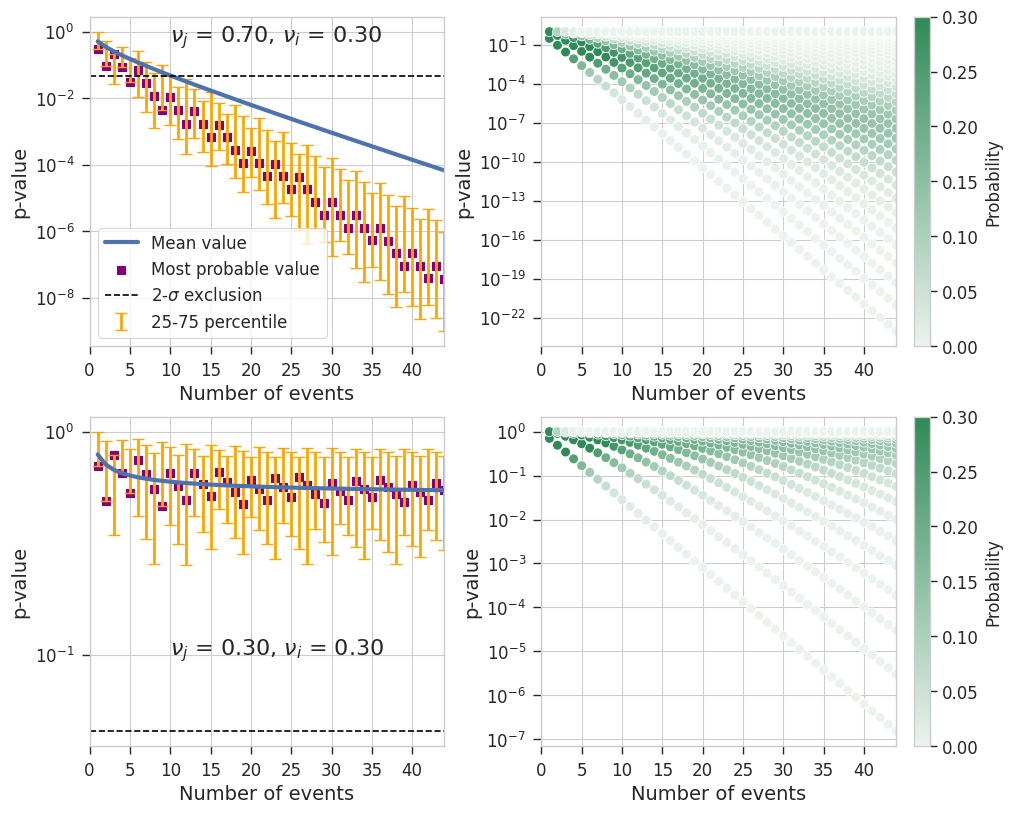

In [28]:

norm = plt.Normalize(0, 0.3)
sm = plt.cm.ScalarMappable(cmap=sn.light_palette("seagreen", as_cmap=True), norm=norm)
n_list = np.arange(1, 45)
nu_exp_list=[0.7, 0.3]
nu_true = 0.3
#[0.9, 0.7, 0.5, 0.3]
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(10,8), layout="constrained")
for j in range(len(nu_exp_list)):
    axs = axes[j]
    nu_exp = nu_exp_list[j]
    if j==0:
        axs[0].text(10, 0.5, fr"$\nu_j$ = {nu_exp:.2f}, $\nu_i$ = {nu_true:.2f}", fontsize=16)
    else:
        axs[0].text(10, 0.1, fr"$\nu_j$ = {nu_exp:.2f}, $\nu_i$ = {nu_true:.2f}", fontsize=16)
    p_values = [[0]*(n) for n in n_list]
    probabilities = [[0]*(n) for n in n_list]
    mean_vals = np.zeros(len(n_list))
    most_prob_vals = np.zeros(len(n_list))
    err_up = np.zeros(len(n_list))
    err_down = np.zeros(len(n_list))

    for i in range(len(n_list)):
        n=n_list[i]
        k_list = np.arange(0, n+1)
        #The actual probabilities
        probabilities[i] = [binomial_probability(k, n, nu_true) for k in k_list]
        probs = np.array(probabilities[i])
        #p values of the theory we are testing
        p_values[i] = np.array([p_value(k, n, nu_exp, stat="binomial") for k in k_list])
        sn.scatterplot(x=[n_list[i]]*len(p_values[i]), y=p_values[i], s=50, hue=probs, hue_norm=norm, legend=False, ax=axs[1], palette=sn.light_palette("seagreen", as_cmap=True))
        mean_vals[i] = np.array(p_values[i]*probs).sum()
        most_prob_vals[i] = p_values[i][probs.argmax()]
        err_down[i], err_up[i] = weighted_percentile(p_values[i], probs, 25, 75)

    #axs[0].scatter(n_list, err_down, label="Approx 25 percentile", color="red", s=50, alpha=0.5)
    #axs[0].scatter(n_list, err_up, label="Approx 75 percentile", color="blue", s=50, alpha=0.5)
    axs[0].errorbar(n_list, err_down, yerr=(np.zeros(len(err_down)), np.abs(err_up-err_down)), capsize=4, elinewidth=2, color="orange", label="25-75 percentile", fmt='none')
    axs[0].plot(n_list, mean_vals, label="Mean value", linewidth=3)
    axs[0].scatter(n_list, most_prob_vals, s=30, marker="s", label="Most probable value", color="purple")
    axs[0].plot([0,45], [0.0455, 0.0455], linestyle="--", label=r"2-$\sigma$ exclusion", color="black")


    #axs[1].figure.colorbar(sm, ax=axs[1], label="Probability")
    cbar = axs[1].figure.colorbar(sm, ax=axs[1])
    cbar.set_label(label="Probability", size=12)
    cbar.ax.tick_params(labelsize=12)

for ax in axes.flatten():
    ax.set_xlabel("Number of events", fontsize=14)
    ax.set_ylabel("p-value", fontsize=14)
    ax.set_yscale("log")
    #ax.set_ylim(10**(-3), max(mean_vals)+0.1)
    ax.set_xlim(n_list[0]-1, n_list[-1])
    ax.tick_params(which="major", direction="out", bottom=True, left=True, pad=5, length=6, width=1, labelsize=12)
    ax.set_xticks(np.arange(0, 45, 5))

axes[0][0].legend(fontsize=12)
fig.savefig(f"../results/figures/p_value_frequency_distributions.pdf", format="pdf", bbox_inches='tight')

## The experimental results

In [13]:
cf_matrix[:,1]

array([0.03886667, 0.77173333, 0.08166667, 0.09673333, 0.11213333,
       0.00966667])

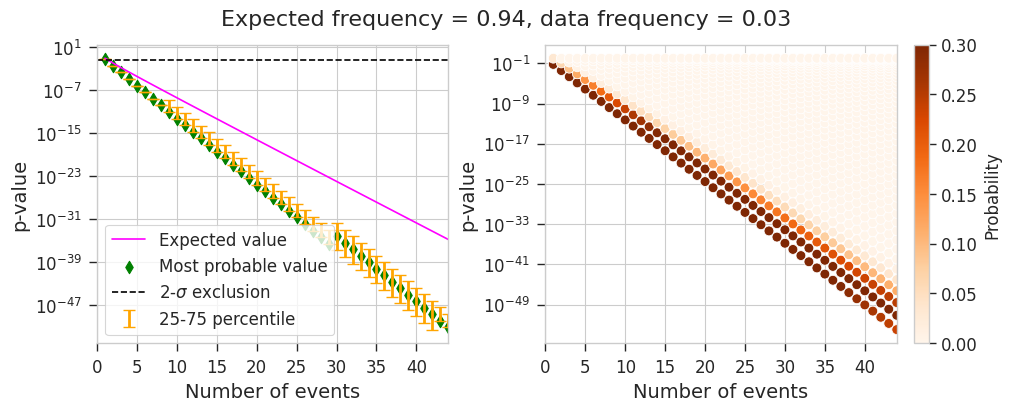

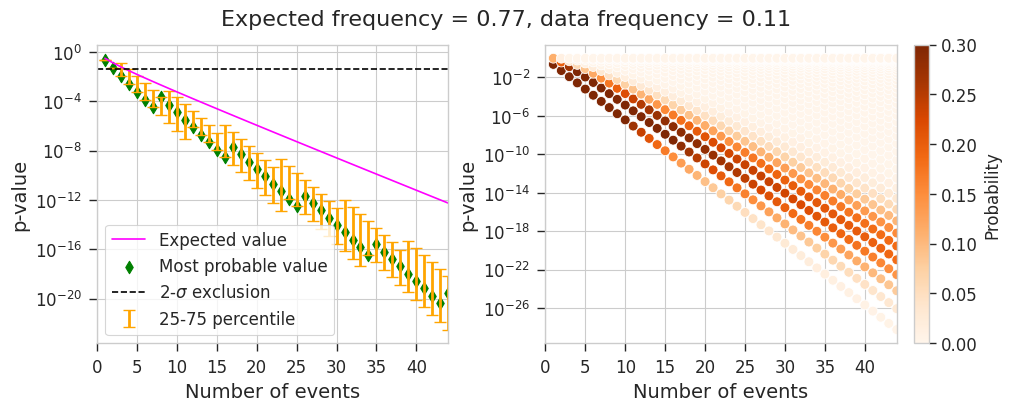

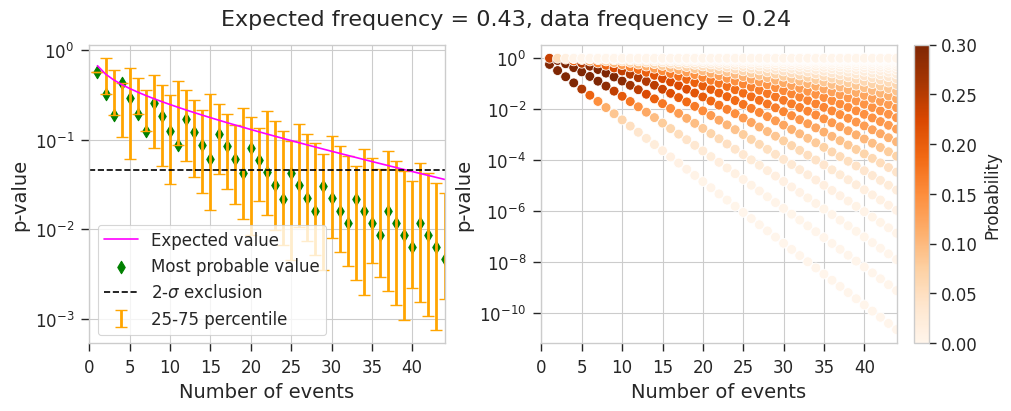

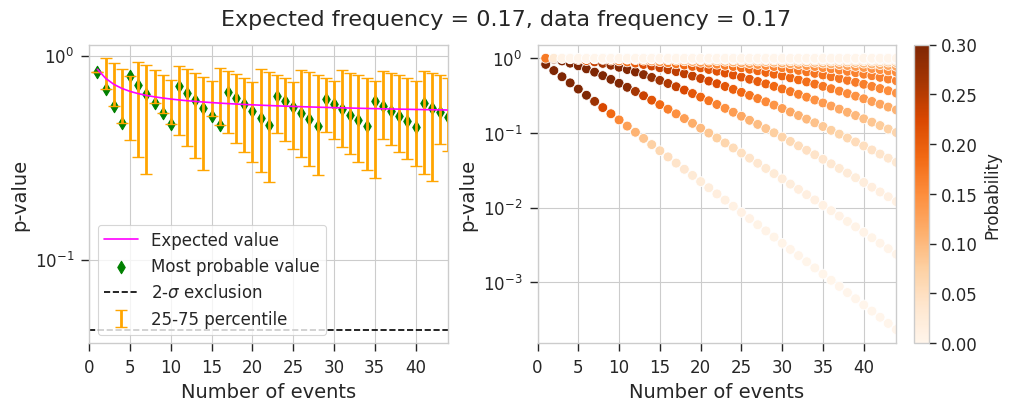

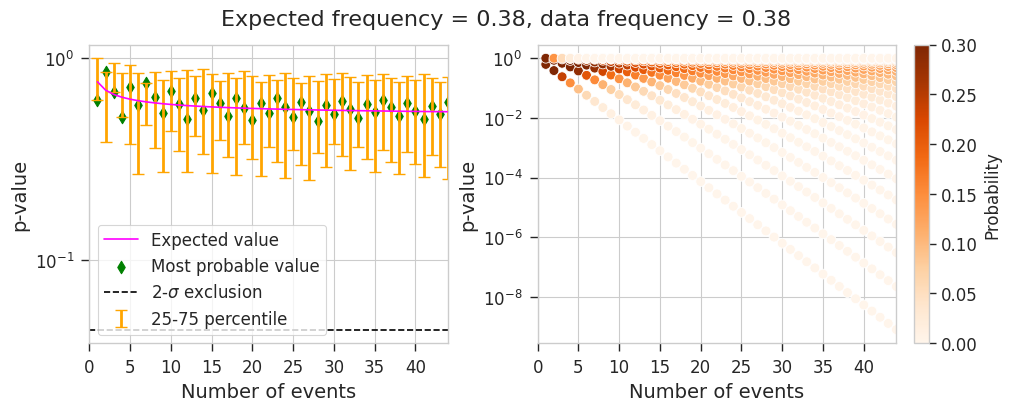

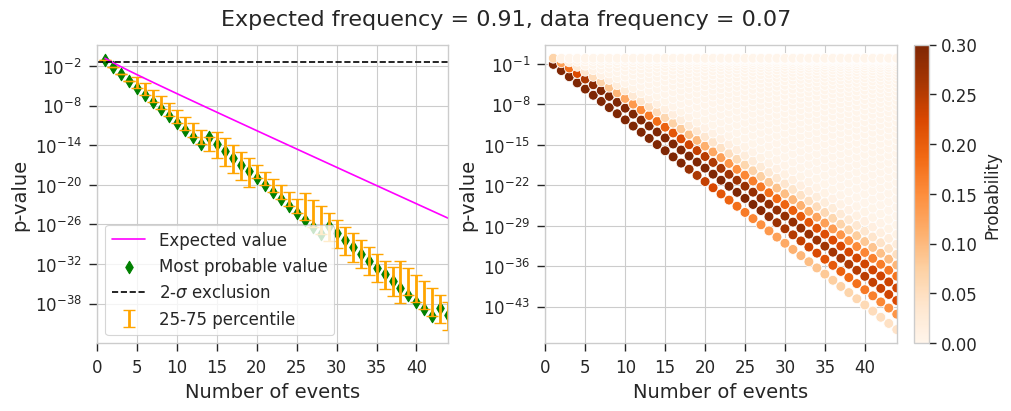

In [14]:

norm = plt.Normalize(0, 0.3)
sm = plt.cm.ScalarMappable(cmap="Oranges", norm=norm)
n_list = np.arange(1, 45)
data=4
nu_exp_list=expected_frequencies
nu_true_list=cf_matrix[data]
#[0.9, 0.7, 0.5, 0.3]

for j in range(len(nu_exp_list)):
    fig, axs = plt.subplots(ncols=2, figsize=(10,4), layout="constrained")
    nu_exp = nu_exp_list[j]
    nu_true = nu_true_list[j]
    fig.suptitle(f"Expected frequency = {nu_exp:.2f}, data frequency = {nu_true:.2f}", fontsize=16)
    p_values = [[0]*(n) for n in n_list]
    probabilities = [[0]*(n) for n in n_list]
    mean_vals = np.zeros(len(n_list))
    most_prob_vals = np.zeros(len(n_list))
    err_up = np.zeros(len(n_list))
    err_down = np.zeros(len(n_list))

    for i in range(len(n_list)):
        n=n_list[i]
        k_list = np.arange(0, n+1)
        #The actual probabilities
        probabilities[i] = [binomial_probability(k, n, nu_true) for k in k_list]
        probs = np.array(probabilities[i])
        #p values of the theory we are testing
        p_values[i] = np.array([p_value(k, n, nu_exp, stat="binomial") for k in k_list])
        sn.scatterplot(x=[n_list[i]]*len(p_values[i]), y=p_values[i], s=50, hue=probs, hue_norm=norm, legend=False, ax=axs[1], palette="Oranges")
        mean_vals[i] = np.array(p_values[i]*probs).sum()
        most_prob_vals[i] = p_values[i][probs.argmax()]
        err_down[i], err_up[i] = weighted_percentile(p_values[i], probs, 25, 75)

    #axs[0].scatter(n_list, err_down, label="Approx 25 percentile", color="red", s=50, alpha=0.5)
    #axs[0].scatter(n_list, err_up, label="Approx 75 percentile", color="blue", s=50, alpha=0.5)
    axs[0].errorbar(n_list, err_down, yerr=(np.zeros(len(err_down)), np.abs(err_up-err_down)), capsize=4, elinewidth=2, color="orange", label="25-75 percentile", fmt='none')
    axs[0].plot(n_list, mean_vals, label="Expected value", color="magenta")
    axs[0].scatter(n_list, most_prob_vals, s=40, marker="d", label="Most probable value", color="green")
    axs[0].plot([0,45], [0.0455, 0.0455], linestyle="--", label=r"2-$\sigma$ exclusion", color="black")


    #axs[1].figure.colorbar(sm, ax=axs[1], label="Probability")
    cbar = axs[1].figure.colorbar(sm, ax=axs[1])
    cbar.set_label(label="Probability", size=12)
    cbar.ax.tick_params(labelsize=12)

    for ax in axs.flatten():
        ax.set_xlabel("Number of events", fontsize=14)
        ax.set_ylabel("p-value", fontsize=14)
        ax.set_yscale("log")
        #ax.set_ylim(10**(-3), max(mean_vals)+0.1)
        ax.set_xlim(n_list[0]-1, n_list[-1])
        ax.tick_params(which="major", direction="out", bottom=True, left=True, pad=5, length=6, width=1, labelsize=12)
        ax.set_xticks(np.arange(0, 45, 5))

    axs[0].legend(fontsize=12)

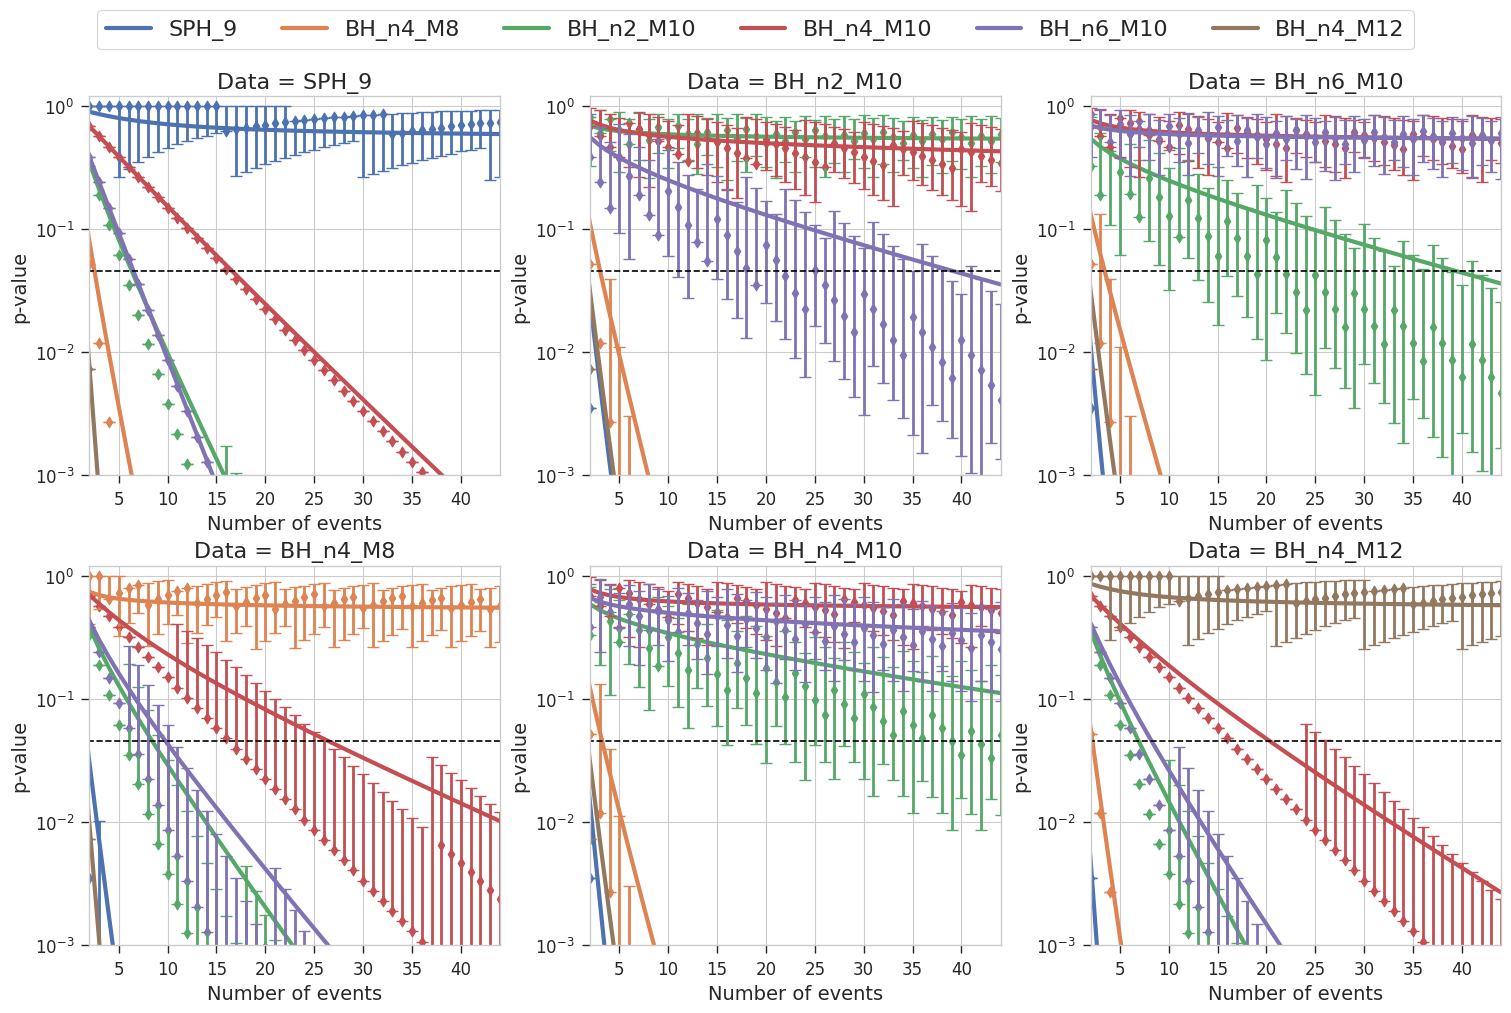

In [29]:
n_list = np.arange(1, 45)
nu_exp_list=expected_frequencies
fig, axs = plt.subplots(ncols = 3, nrows=2, figsize=(15, 10), layout="constrained")
tol=0.000001
for d in range(len(LABELS)):
    nu_true_list=cf_matrix[d]
    ax = axs[d%2][d//2]
    for j in range(len(nu_exp_list)): #Iterate over each hypothesis
        nu_exp = nu_exp_list[j]
        nu_true = nu_true_list[j]
        ax.set_title(f"Data = {LABELS[d]}", fontsize=16)
        p_values = [[0]*(n) for n in n_list]
        mean_vals = np.zeros(len(n_list))
        err_up = np.zeros(len(n_list))
        err_down = np.zeros(len(n_list))

        for i in range(len(n_list)):
            n=n_list[i]
            k_list = np.arange(0, n+1)
            #The actual probabilities
            probs = np.array([binomial_probability(k, n, nu_true) for k in k_list])
            #p values of the theory we are testing
            p_values[i] = np.array([p_value(k, n, nu_exp, stat="binomial") for k in k_list])
            mean_vals[i] = np.array(p_values[i]*probs).sum()
            err_down[i], err_up[i] = weighted_percentile(p_values[i], probs, 25, 75)
            idx_most_prob = np.where((probs >= probs[np.argmax(probs)] - tol) & (probs <= probs[np.argmax(probs)] + tol))[0]
            ax.scatter([n]*len(idx_most_prob), p_values[i][idx_most_prob], marker="d", s=30, color=paper_colors[j])
        ax.errorbar(n_list, err_down, yerr=(np.zeros(len(err_down)), np.abs(err_up-err_down)), capsize=4, elinewidth=2, color=paper_colors[j], fmt='none')
        ax.plot(n_list, mean_vals, linewidth=3, label=f"{LABELS[j]}", color=paper_colors[j])
    ax.plot([0,45], [0.0455, 0.0455], linestyle="--", color="black")

fig.suptitle(f"      ", x=0.1, va="top", fontsize=40)
handles, labels = axs[0][0].get_legend_handles_labels()
#labels = [fr"{hue_key} = {label}" for label in labels]
fig.legend(handles, labels, loc='upper center', ncol=6, labelspacing=0.1, fontsize=16, frameon=True)

for ax in axs.flatten():
    ax.set_xlabel("Number of events", fontsize=14)
    ax.set_ylabel("p-value", fontsize=14)
    ax.set_yscale("log")
    ax.set_ylim(10**(-3),1.2)
    ax.set_xlim(n_list[0]-1, n_list[-1])
    ax.tick_params(which="major", direction="out", bottom=True, left=True, pad=5, length=6, width=1, labelsize=12)
    ax.set_xticks(np.arange(0, 45, 5))
    ax.set_xlim(2, 44)
    #ax.legend(fontsize=12)
fig.savefig(f"../results/figures/thesis_ensemble_binomial_p_values_analytical.pdf", format="pdf", bbox_inches='tight')